In [1]:
# Test_earthquake_classifier_week4
## 1. Import Necessary Libraries
## 2. Load and Explore the dataset
# 2.1 Explore the target variable: to know which feature should be kept or drop
## 3. Splitting Data into Training and Test Sets
## 4. Data Preprocessing
## 5. Model Fitting, Test, Evaluation  
# 6. Evaluation models

## 1. Import Necessary Libraries

In [2]:
# Data manipulation and visualization libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from ydata_profiling import ProfileReport
%matplotlib inline

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder

from sklearn.linear_model import LinearRegression 
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.svm import LinearSVR  

from lazypredict.Supervised import LazyRegressor

## 2. Load and Explore data

In [3]:
df = pd.read_csv("C:\\Users\\Dell\\Desktop\\AAA 2024\\2024 Python Data Science\\Machine Learning\\earthquake_data.csv")
print(df.head())
print(df.info())

                                          title  magnitude         date_time  \
0  M 7.0 - 18 km SW of Malango, Solomon Islands       7.00  22-11-2022 02:03   
1      M 6.9 - 204 km SW of Bengkulu, Indonesia       6.90  18-11-2022 13:37   
2                                      M 7.0 -        7.00  12-11-2022 07:09   
3           M 7.3 - 205 km ESE of Neiafu, Tonga       7.30  11-11-2022 10:48   
4                                      M 6.6 -        6.60  09-11-2022 10:14   

   cdi  mmi  alert  tsunami  sig net  nst  dmin   gap magType  depth  \
0    8    7  green        1  768  us  117  0.51 17.00     mww  14.00   
1    4    4  green        0  735  us   99  2.23 34.00     mww  25.00   
2    3    3  green        1  755  us  147  3.12 18.00     mww 579.00   
3    5    5  green        1  833  us  149  1.86 21.00     mww  37.00   
4    0    2  green        1  670  us  131  5.00 27.00     mww 624.46   

   latitude  longitude                  location continent          country  
0     -9

Earthquake dataset

Datasets contain records of 782 earthquakes from 1/1/2001 to 1/1/2023. The meaning of all columns is as follows:

title: title name given to the earthquake

magnitude: The magnitude of the earthquake

date_time: date and time

cdi: The maximum reported intensity for the event range

mmi: The maximum estimated instrumental intensity for the event

alert: The alert level - “green”, “yellow”, “orange”, and “red”

tsunami: "1" for events in oceanic regions and "0" otherwise

sig: A number describing how significant the event is. Larger numbers indicate a more significant event. This value is determined on a number of factors, including: magnitude, maximum MMI, felt reports, and estimated impact

net: The ID of a data contributor. Identifies the network considered to be the preferred source of information for this event.

nst: The total number of seismic stations used to determine earthquake location.

dmin: Horizontal distance from the epicenter to the nearest station

gap: The largest azimuthal gap between azimuthally adjacent stations (in degrees). In general, the smaller this number, the more reliable is the calculated horizontal position of the earthquake. Earthquake locations in which the azimuthal gap exceeds 180 degrees typically have large location and depth uncertainties

magType: The method or algorithm used to calculate the preferred magnitude for the event

depth: The depth where the earthquake begins to rupture

latitude / longitude: coordinate system by means of which the position or location of any place on Earth's surface can be determined and described

location: location within the country

continent: continent of the earthquake hit country

country: affected country

In [4]:
profile = ProfileReport(df, title = "Earthquake_dataset_Report", explorative=True)
profile.to_file("report_Earthquake_dataset.html")
print(os.path.abspath("report_Earthquake_dataset.html"))

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\Dell\report_Earthquake_dataset.html


title          0
magnitude      0
date_time      0
cdi            0
mmi            0
alert        367
tsunami        0
sig            0
net            0
nst            0
dmin           0
gap            0
magType        0
depth          0
latitude       0
longitude      0
location       5
continent    576
country      298
dtype: int64


<Axes: >

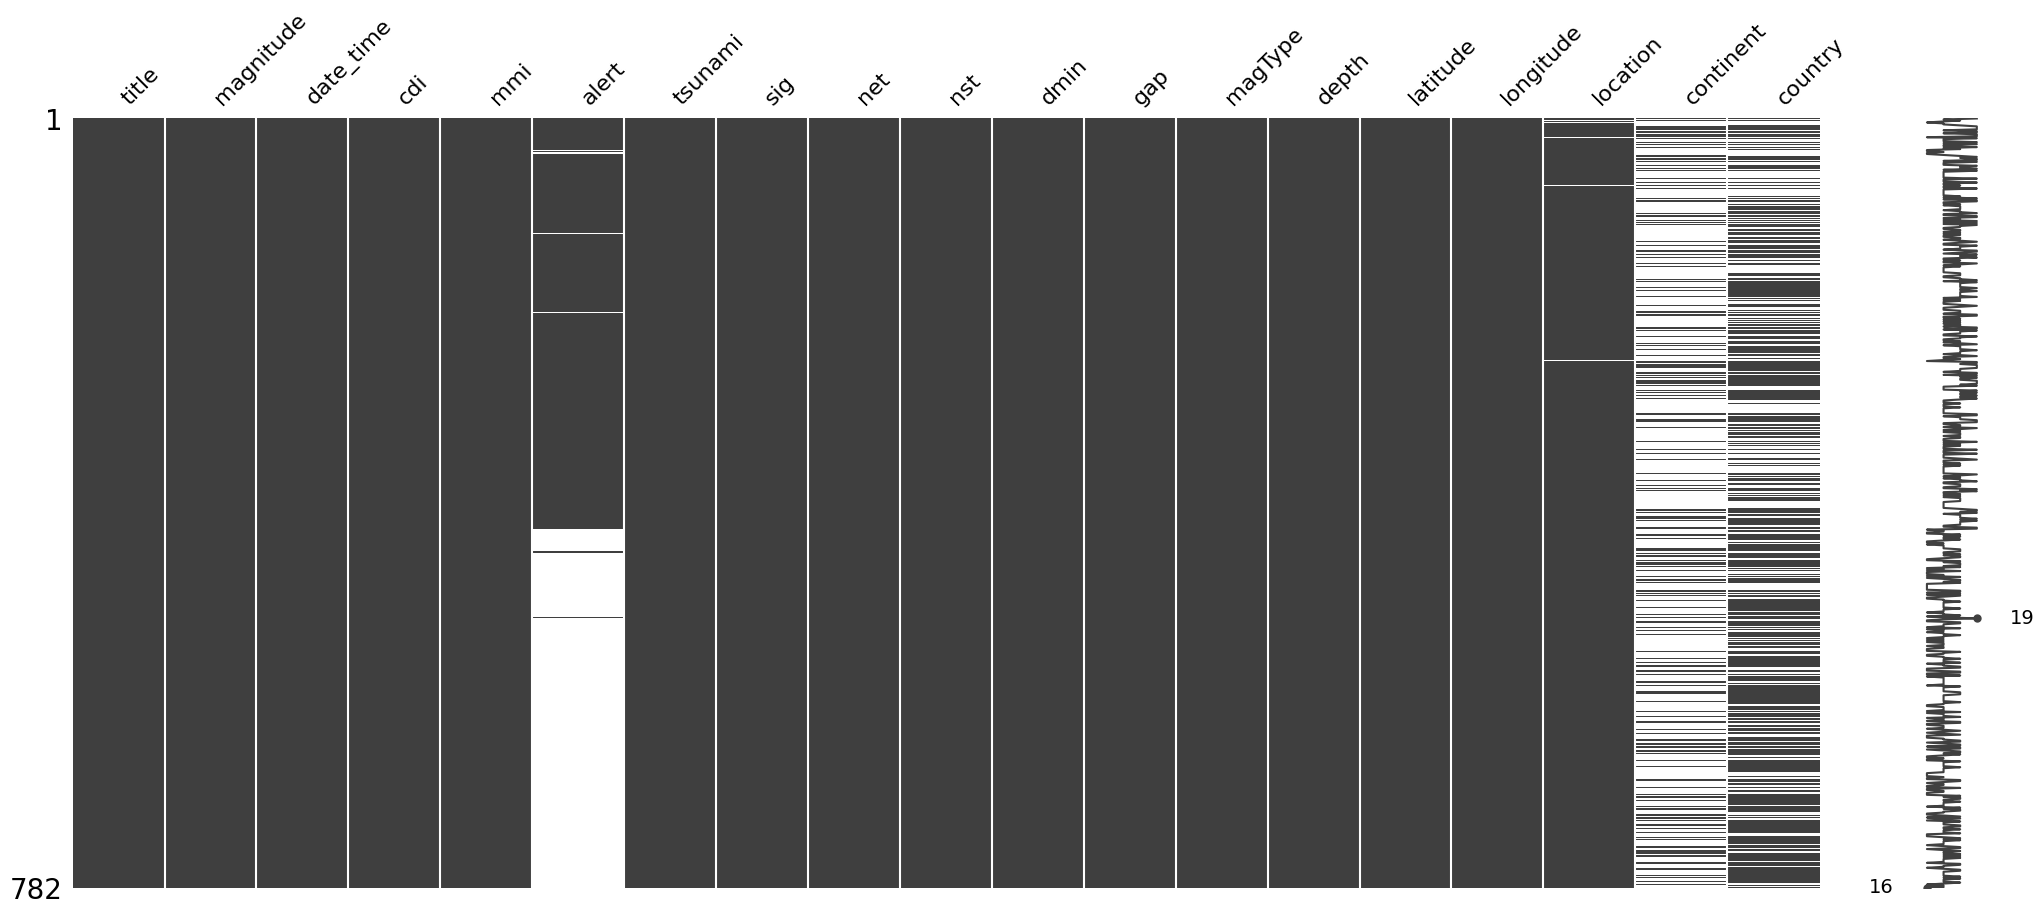

In [5]:
missing_counts = df.isnull().sum()
print(missing_counts)
msno.matrix(df)

In [6]:
print(df.duplicated().sum())

0


In [7]:
# Check for 0 values 
print((df == 0).sum())

title          0
magnitude      0
date_time      0
cdi          212
mmi            0
alert          0
tsunami      478
sig            0
net            0
nst          365
dmin         405
gap           70
magType        0
depth          0
latitude       0
longitude      0
location       0
continent      0
country        0
dtype: int64


In [8]:
# Check columns with exactly 2 unique values
print("Columns with exactly 2 unique values:")
for col in df.columns:
    unique_values = df[col].dropna().unique()  
    if len(unique_values) == 2:
        print(f"Column '{col}':")
        print(df[col].value_counts())

Columns with exactly 2 unique values:
Column 'tsunami':
tsunami
0    478
1    304
Name: count, dtype: int64


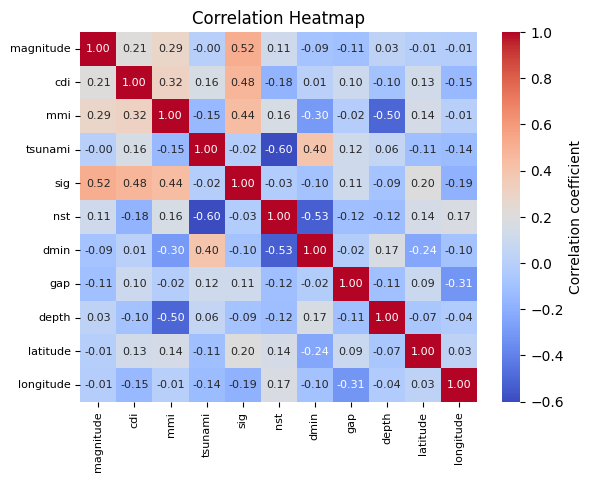

In [9]:
# correlation matrix
numeric_data = df.select_dtypes(include=['float64', 'int64'])

sns.heatmap(numeric_data.corr(), annot=True, 
             cmap="coolwarm", fmt=".2f", annot_kws={"size": 8}, 
             cbar_kws={'label': 'Correlation coefficient'})
plt.title("Correlation Heatmap")
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

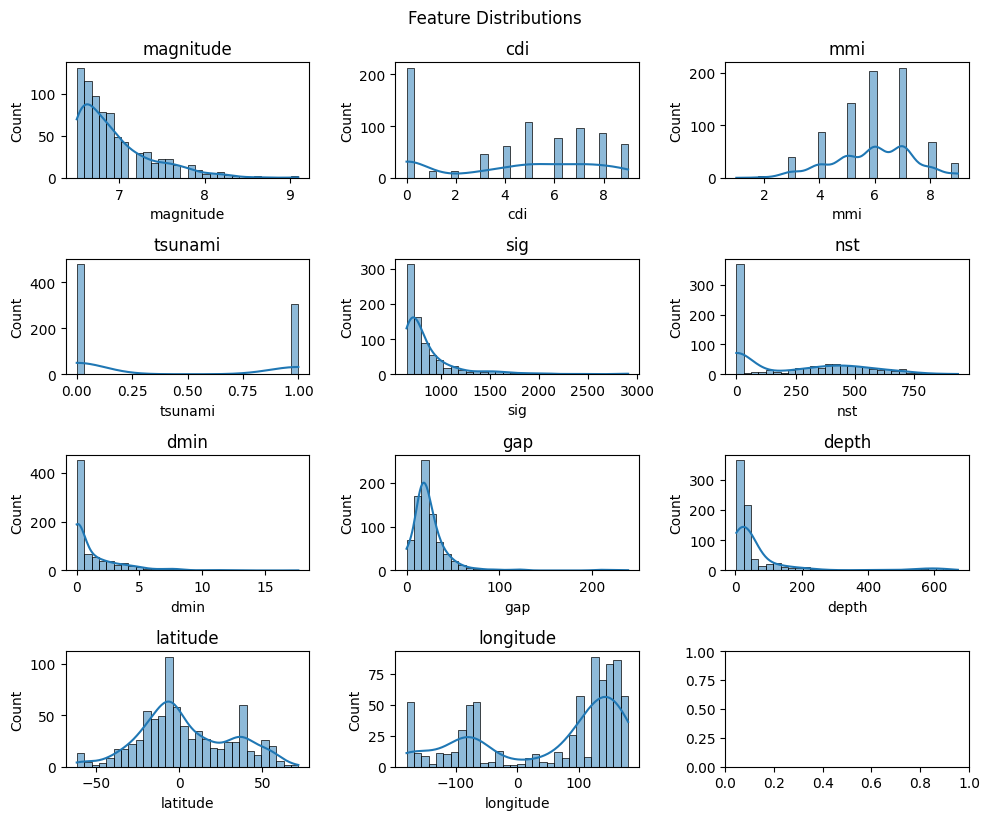

In [10]:
# Feature Distributions: Visualize numeric features to understand their distribution
# Helps identify skewness, outliers, and check normality for preprocessing decisions.
numeric_columns = df.select_dtypes(include=['number']).columns

fig, axes = plt.subplots(4, 3, figsize=(10, 8))
axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    sns.histplot(data=df, x=column, kde=True, bins=30, ax=axes[i])  
    axes[i].set_title(f'{column}')  
plt.tight_layout()
plt.suptitle("Feature Distributions", y=1.02)  
plt.show()

In [11]:
# Skewness and kurtosis help evaluate the distribution of numerical features
# Skewness close to 0 suggests a symmetric distribution, 
# positive skew (>0) indicates a right tail,  
# negative skew (<0) indicates a left tail.

# Kurtosis values around 3 indicate a normal distribution. 
# Values > 3 suggest heavy tails (outliers), 
# while < 3 suggests light tails.

print("Skewness for numerical columns:")
print(df.select_dtypes(include=['number']).skew())

print("Kurtosis for numerical columns:")
print(df.select_dtypes(include=['number']).kurt())

Skewness for numerical columns:
magnitude    1.44
cdi         -0.20
mmi         -0.25
tsunami      0.46
sig          3.08
nst          0.53
dmin         2.60
gap          4.67
depth        3.02
latitude     0.20
longitude   -0.70
dtype: float64
Kurtosis for numerical columns:
magnitude    2.23
cdi         -1.36
mmi         -0.22
tsunami     -1.80
sig         12.00
nst         -1.09
dmin         9.28
gap         32.03
depth        8.38
latitude    -0.48
longitude   -1.09
dtype: float64


Number of outliers in each column: 
magnitude     37
cdi            0
mmi            1
tsunami        0
sig           73
nst            0
dmin          61
gap           48
depth        139
latitude       0
longitude      0
dtype: int64


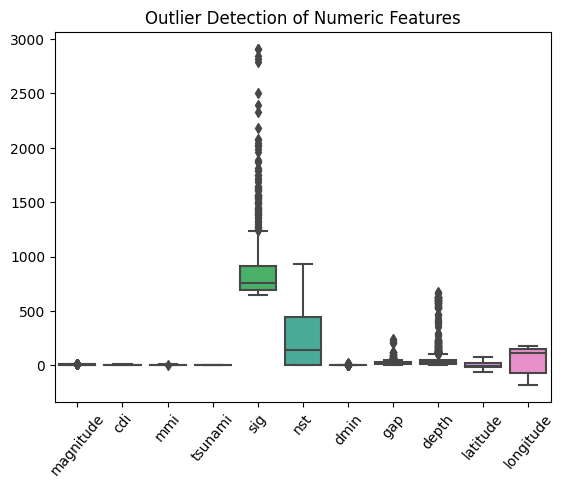

In [12]:
# Outlier Detection 
numeric_df = df.select_dtypes(include=['float64', 'int64'])
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).sum()
print(f"Number of outliers in each column: \n{outliers}")

# Visualize outliers 
sns.boxplot(data=numeric_df)
plt.title("Outlier Detection of Numeric Features")
plt.xticks(rotation=50)
plt.show()

In [13]:
df['date_time'] = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M')
print(df['date_time'].head())

0   2022-11-22 02:03:00
1   2022-11-18 13:37:00
2   2022-11-12 07:09:00
3   2022-11-11 10:48:00
4   2022-11-09 10:14:00
Name: date_time, dtype: datetime64[ns]


In [14]:
# Clean object columns by removing spaces, converting to lowercase
object_columns = df.select_dtypes(include=['object']).columns
for column in object_columns:
    df[column] = df[column].str.strip().str.replace(' ', '').str.lower()
print(df.head())

                                 title  magnitude           date_time  cdi  \
0  m7.0-18kmswofmalango,solomonislands       7.00 2022-11-22 02:03:00    8   
1     m6.9-204kmswofbengkulu,indonesia       6.90 2022-11-18 13:37:00    4   
2                                m7.0-       7.00 2022-11-12 07:09:00    3   
3          m7.3-205kmeseofneiafu,tonga       7.30 2022-11-11 10:48:00    5   
4                                m6.6-       6.60 2022-11-09 10:14:00    0   

   mmi  alert  tsunami  sig net  nst  dmin   gap magType  depth  latitude  \
0    7  green        1  768  us  117  0.51 17.00     mww  14.00     -9.80   
1    4  green        0  735  us   99  2.23 34.00     mww  25.00     -4.96   
2    3  green        1  755  us  147  3.12 18.00     mww 579.00    -20.05   
3    5  green        1  833  us  149  1.86 21.00     mww  37.00    -19.29   
4    2  green        1  670  us  131  5.00 27.00     mww 624.46    -25.59   

   longitude                location continent         country  
0  

In [15]:
# EDA the target variable 

Target Class Distribution:
magnitude
6.50    131
6.60    115
6.70     98
6.80     78
6.90     77
7.00     49
7.10     43
7.30     31
7.20     30
7.60     22
7.50     22
7.40     18
7.70     16
7.80     15
7.90      9
8.20      6
8.10      6
8.00      5
8.30      3
8.60      2
9.10      2
8.40      2
8.80      1
8.16      1
Name: count, dtype: int64

Target Class Distribution (Percentage):
magnitude
6.50   0.17
6.60   0.15
6.70   0.13
6.80   0.10
6.90   0.10
7.00   0.06
7.10   0.05
7.30   0.04
7.20   0.04
7.60   0.03
7.50   0.03
7.40   0.02
7.70   0.02
7.80   0.02
7.90   0.01
8.20   0.01
8.10   0.01
8.00   0.01
8.30   0.00
8.60   0.00
9.10   0.00
8.40   0.00
8.80   0.00
8.16   0.00
Name: proportion, dtype: float64


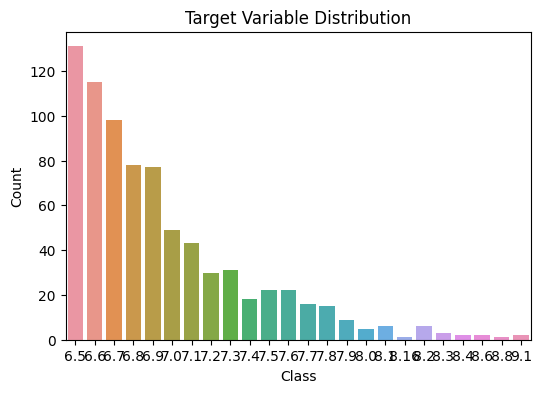

In [15]:
print("Target Class Distribution:")
print(df['magnitude'].value_counts())
print("\nTarget Class Distribution (Percentage):")
print(df['magnitude'].value_counts(normalize=True))

# Visualize target distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='magnitude', data=df)
plt.title('Target Variable Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()


Grouped Mean Statistics (Numerical Features):
           magnitude       cdi       mmi   tsunami          sig         nst  \
magnitude                                                                     
6.50            6.50  3.412214  5.534351  0.381679   711.916031  182.977099   
6.60            6.60  3.826087  5.800000  0.373913   746.965217  212.217391   
6.70            6.70  3.928571  5.683673  0.326531   766.571429  233.397959   
6.80            6.80  3.730769  5.666667  0.410256   774.666667  240.858974   
6.90            6.90  4.883117  5.701299  0.480519   858.207792  171.428571   
7.00            7.00  5.102041  6.285714  0.428571   923.673469  255.816327   
7.10            7.10  4.790698  6.186047  0.441860   949.883721  262.697674   
7.20            7.20  4.866667  6.400000  0.300000  1016.966667  332.466667   
7.30            7.30  4.806452  6.000000  0.419355  1063.483871  252.354839   
7.40            7.40  3.500000  6.611111  0.277778  1008.055556  367.000000   
7.50 

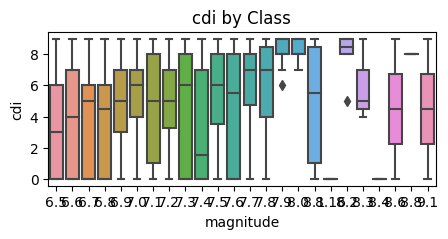

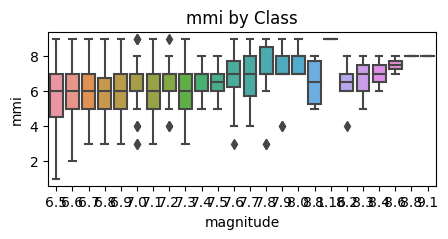

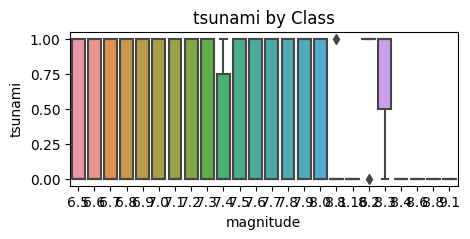

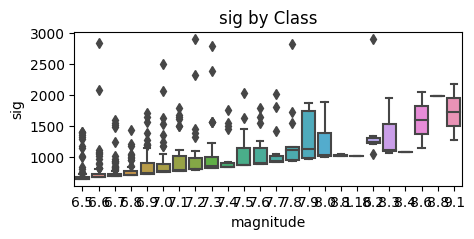

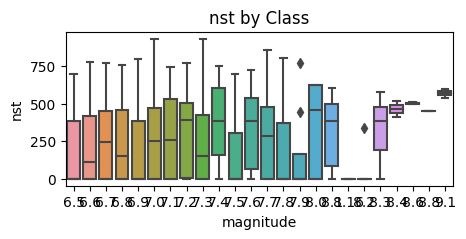

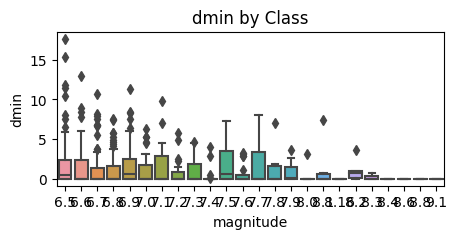

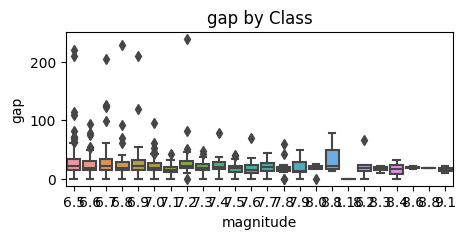

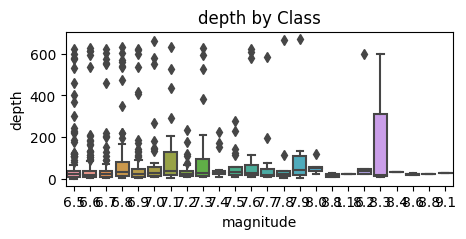

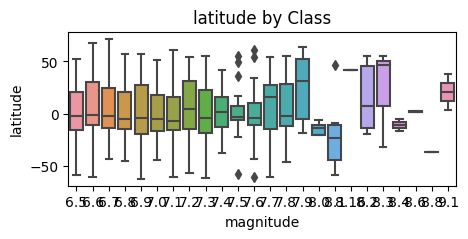

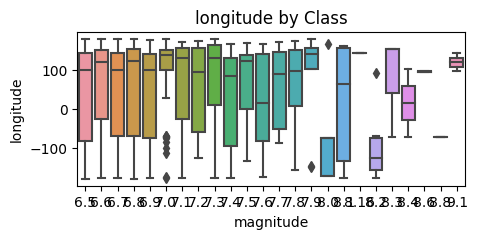

In [18]:
# Step 2: Grouped Mean Statistics
# This step helps decide whether to retain, drop, or transform numerical features based on their correlation with the target.
# Help to find out features should be kept for their potential to differentiate between the target variable class. 

print("\nGrouped Mean Statistics (Numerical Features):")
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
grouped_stats = df.groupby('magnitude')[numeric_columns].mean()
print(grouped_stats)

# Boxplots for numerical features by target class
for column in numeric_columns:
    if column != 'magnitude':  # Exclude the target column itself
        plt.figure(figsize=(5, 2))
        sns.boxplot(x='magnitude', y=column, data=df)
        plt.title(f'{column} by Class')
        plt.show()

Numeric Columns:
 Index(['magnitude', 'cdi', 'mmi', 'tsunami', 'sig', 'nst', 'dmin', 'gap',
       'depth', 'latitude', 'longitude'],
      dtype='object')

Correlation with Target Variable 'magnitude':
magnitude    1.000000
sig          0.515871
mmi          0.285552
cdi          0.209549
nst          0.113114
depth        0.030644
tsunami     -0.004726
latitude    -0.008552
longitude   -0.013911
dmin        -0.091403
gap         -0.110626
Name: magnitude, dtype: float64


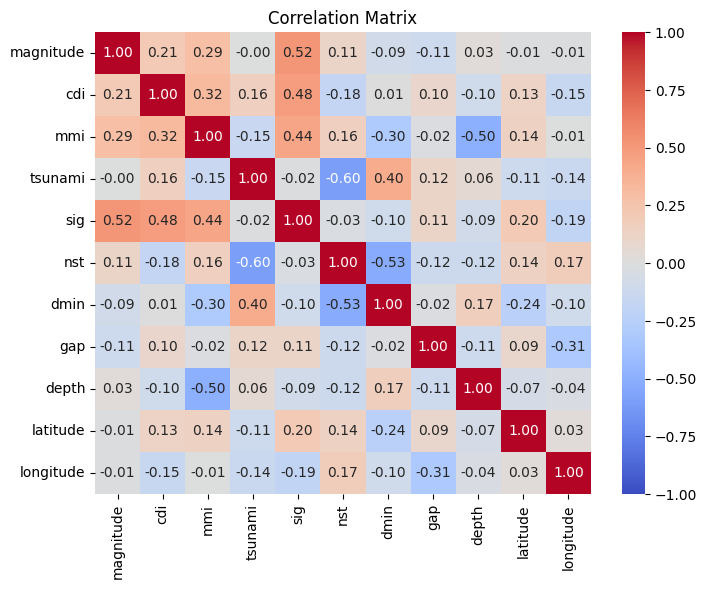

In [19]:
# Step 3: Target-Oriented Correlation Analysis
# This step helps identify the relationship between features and the target variable, 
# Shows which features have strong correlations with the target, suggesting they are useful for prediction.
# Feature Selection: Features with weak or no correlation with the target may be dropped.

# Step: Select numeric columns only
numeric_columns = df.select_dtypes(include=['number'])
print("Numeric Columns:\n", numeric_columns.columns)

# Step: Compute correlation matrix
correlation = numeric_columns.corr()

# Step: Display correlation with the target variable 'tsunami'
print("\nCorrelation with Target Variable 'magnitude':")
print(correlation['magnitude'].sort_values(ascending=False))


plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()




Proportions for Categorical Features by Target Class:

title Proportions by Target Class:

alert Proportions by Target Class:
alert   magnitude
green   6.5          0.206154
        6.6          0.156923
        6.9          0.132308
        6.7          0.126154
        6.8          0.107692
        7.0          0.061538
        7.1          0.052308
        7.3          0.033846
        7.2          0.021538
        7.5          0.021538
        7.6          0.012308
        7.8          0.012308
        7.4          0.012308
        7.7          0.012308
        7.9          0.009231
        8.2          0.009231
        8.1          0.006154
        8.0          0.003077
        8.3          0.003077
orange  6.7          0.136364
        7.1          0.136364
        6.6          0.136364
        7.3          0.090909
        6.9          0.090909
        7.8          0.090909
        8.3          0.045455
        7.5          0.045455
        8.0          0.045455
        7.0    

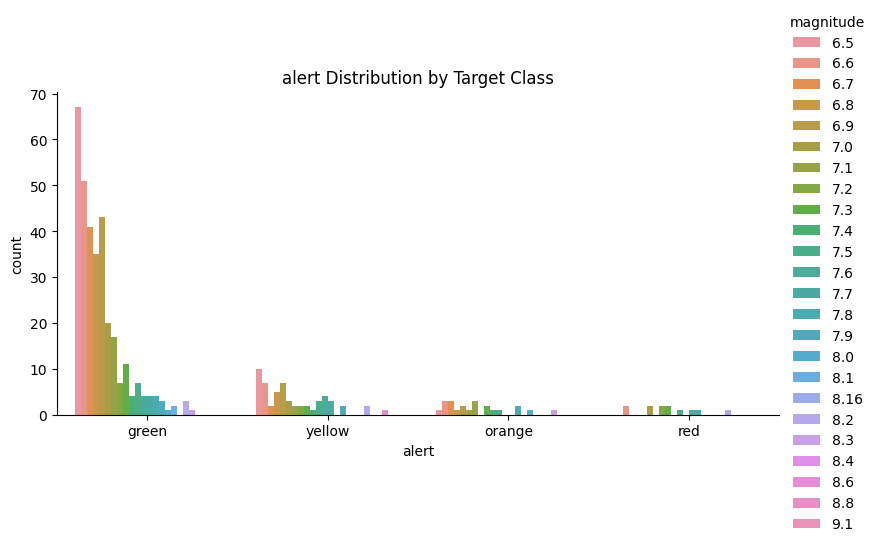

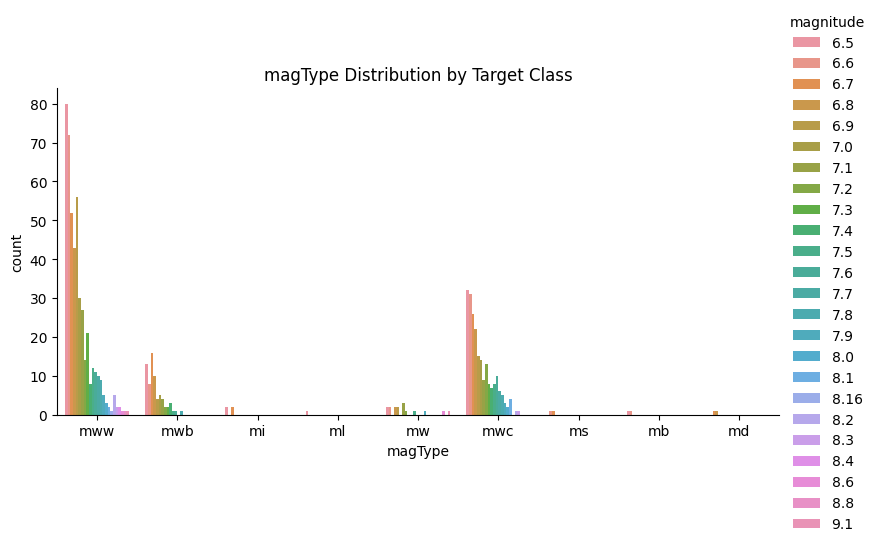

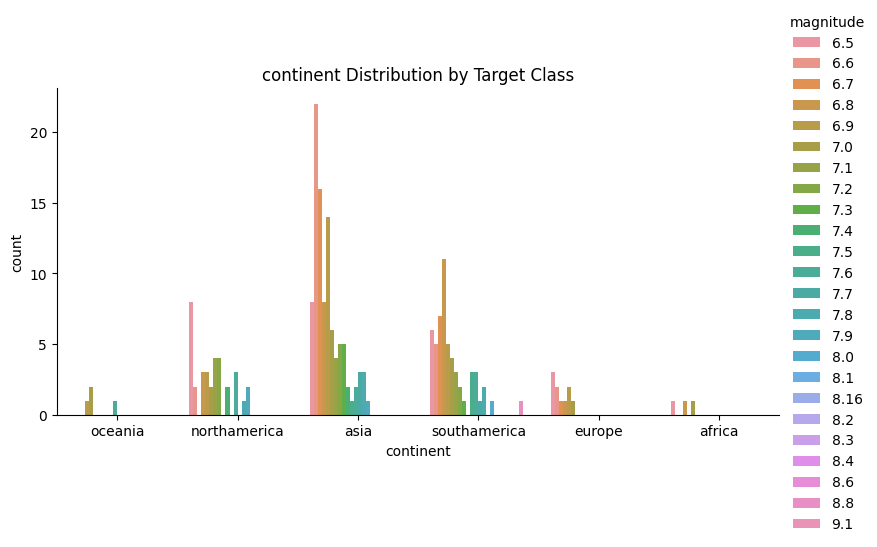

In [20]:
# Step 4: Categorical Features Analysis Vs Target 
# The goal of analyzing categorical features by their proportions with the target is 
# to identify if the features provide meaningful information to predict the target variable.

categorical_columns = df.select_dtypes(include=['object']).columns
print("\nProportions for Categorical Features by Target Class:")
for column in categorical_columns:
    print(f"\n{column} Proportions by Target Class:")
    if df[column].nunique() <= 10:  # Limit for readability
        print(df.groupby(column)['magnitude'].value_counts(normalize=True))

# Visualize categorical distributions
for column in categorical_columns:
    if df[column].nunique() <= 10:  # Visualize only manageable unique values
        sns.catplot(x=column, hue='magnitude', data=df, kind='count', height=4, aspect=2)
        plt.title(f'{column} Distribution by Target Class')
        plt.show()

In [21]:
# Step 5: Check Missing Values in Target
print("\nMissing and Unique Values in Target Variable:")
print(f"Missing Values : {df['magnitude'].isnull().sum()}")
print(f"Unique Values : {df['magnitude'].unique()}")


Missing and Unique Values in Target Variable:
Missing Values : 0
Unique Values : [7.   6.9  7.3  6.6  6.8  6.7  7.6  6.5  7.2  7.5  7.1  8.1  8.2  7.4
 7.7  7.8  8.   7.9  8.3  8.6  9.1  8.8  8.4  8.16]


In [22]:
# Group columns by their data types
for dtype in df.dtypes.unique():
    print(f"\n{dtype} columns:")
    print(df.select_dtypes(include=[dtype]).columns.tolist())


object columns:
['title', 'alert', 'net', 'magType', 'location', 'continent', 'country']

float64 columns:
['magnitude', 'dmin', 'gap', 'depth', 'latitude', 'longitude']

datetime64[ns] columns:
['date_time']

int64 columns:
['cdi', 'mmi', 'tsunami', 'sig', 'nst']


## 3. Splitting Data into Training and Test Sets

In [74]:
# Define features (X) and target (y)
# Numerical Features to Drop: 
# ['tsunami', 'dmin', 'gap','latitude', 'longitude']
# (low correlation with tsunami).
# Categorical Features to Drop: ['title', 'net', 'location', 'country', 'date_time']
# (due to missing values and low relevance).

drop_columns = ['tsunami', 'dmin', 'gap','latitude', 'longitude','title', 'net', 'location', 'country', 'date_time' ]  
x = df.drop(columns=drop_columns + ['magnitude'])  
y = df['magnitude']  

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Print shapes and preview
print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_test: {x_test.shape}, y_test: {y_test.shape}")
print(x_train.head())
print(x_train.dtypes)

x_train: (625, 8), y_train: (625,)
x_test: (157, 8), y_test: (157,)
     cdi  mmi  alert   sig  nst magType  depth continent
602    8    8    NaN   831  782     mwc  12.00      Asia
133    0    5  green   650    0     mww  38.00       NaN
239    5    6  green   897    0     mww  19.00       NaN
55     5    4  green   738    0     mww  20.74       NaN
613    8    7    NaN  1023  744     mwb  10.00      Asia
cdi            int64
mmi            int64
alert         object
sig            int64
nst            int64
magType       object
depth        float64
continent     object
dtype: object


## 4. Data Preprocessing

In [75]:
# # ??? Turn off means No handle 0 values, accuracy higher than 
# # ??? Handle 0 values, accuracy lower than 

# # select columns with 0 values
# columns_0_as_missing = [col for col in x_train.columns if (x_train[col] == 0).any()]

# # Replace 0 with NaN in those columns
# x_train[columns_0_as_missing] = x_train[columns_0_as_missing].replace(0, np.nan)
# x_test[columns_0_as_missing] = x_test[columns_0_as_missing].replace(0, np.nan)

# # Verify the changes
# print(f"Columns treated as missing:\n{columns_0_as_missing}")
# print(f"Updated Training Data:\n{x_train[columns_0_as_missing].head()}")

In [76]:
# SimpleImputer for numerical_columns
numerical_columns = x_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_imputer = SimpleImputer(strategy='median')
x_train[numerical_columns] = numerical_imputer.fit_transform(x_train[numerical_columns])
x_test[numerical_columns] = numerical_imputer.transform(x_test[numerical_columns])
# Verify the changes
print(f"Preprocessed Training set:\n{x_train.head()}")

Preprocessed Training set:
     cdi  mmi  alert     sig    nst magType  depth continent
602 8.00 8.00    NaN  831.00 782.00     mwc  12.00      Asia
133 0.00 5.00  green  650.00   0.00     mww  38.00       NaN
239 5.00 6.00  green  897.00   0.00     mww  19.00       NaN
55  5.00 4.00  green  738.00   0.00     mww  20.74       NaN
613 8.00 7.00    NaN 1023.00 744.00     mwb  10.00      Asia


In [77]:
# Handle Outliers by using IQR
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
numerical_columns = x_train.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_columns:
    cap_outliers(x_train, col)
    cap_outliers(x_test, col)
# Verify the changes
print(f"Preprocessed Training set:\n{x_train.head()}")

Preprocessed Training set:
     cdi  mmi  alert     sig    nst magType  depth continent
602 8.00 8.00    NaN  831.00 782.00     mwc  12.00      Asia
133 0.00 5.00  green  650.00   0.00     mww  38.00       NaN
239 5.00 6.00  green  897.00   0.00     mww  19.00       NaN
55  5.00 4.00  green  738.00   0.00     mww  20.74       NaN
613 8.00 7.00    NaN 1023.00 744.00     mwb  10.00      Asia


In [78]:
scaler_robust = RobustScaler()
numerical_columns = x_train.select_dtypes(include=['float64', 'int64']).columns
x_train[numerical_columns] = scaler_robust.fit_transform(x_train[numerical_columns])
x_test[numerical_columns] = scaler_robust.transform(x_test[numerical_columns])
# Verify the changes
print(f"Preprocessed Training set:\n{x_train.head()}")

Preprocessed Training set:
      cdi   mmi  alert   sig   nst magType  depth continent
602  0.43  1.00    NaN  0.34  1.40     mwc  -0.37      Asia
133 -0.71 -0.50  green -0.47 -0.35     mww   0.27       NaN
239  0.00  0.00  green  0.64 -0.35     mww  -0.20       NaN
55   0.00 -1.00  green -0.08 -0.35     mww  -0.16       NaN
613  0.43  0.50    NaN  1.20  1.32     mwb  -0.42      Asia


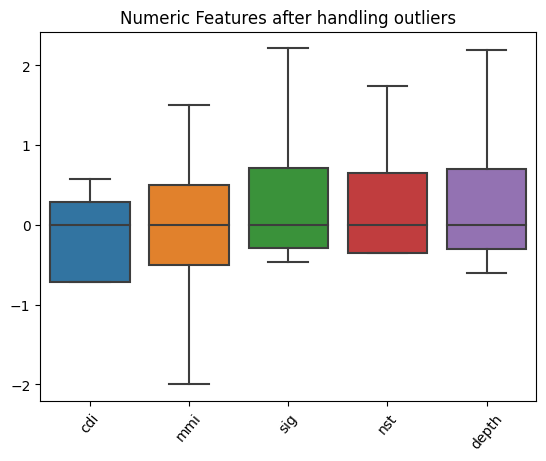

In [79]:
# Plot Numeric features after handling outliers
sns.boxplot(data=x_train[numerical_columns])
plt.title("Numeric Features after handling outliers")
plt.xticks(rotation=50)
plt.show()

In [80]:
print(x_train.dtypes)

cdi          float64
mmi          float64
alert         object
sig          float64
nst          float64
magType       object
depth        float64
continent     object
dtype: object


In [81]:
# SimpleImputer for object_columns
object_columns = x_train.select_dtypes(include=['object']).columns.tolist()
object_imputer = SimpleImputer(strategy='most_frequent')
x_train[object_columns] = object_imputer.fit_transform(x_train[object_columns])
x_test[object_columns] = object_imputer.transform(x_test[object_columns])
# Check for any missing values after imputation
print(x_train[object_columns].isnull().sum())
print(x_test[object_columns].isnull().sum())
# Verify the changes
print(f"Preprocessed Training set:\n{x_train.head()}")

alert        0
magType      0
continent    0
dtype: int64
alert        0
magType      0
continent    0
dtype: int64
Preprocessed Training set:
      cdi   mmi  alert   sig   nst magType  depth continent
602  0.43  1.00  green  0.34  1.40     mwc  -0.37      Asia
133 -0.71 -0.50  green -0.47 -0.35     mww   0.27      Asia
239  0.00  0.00  green  0.64 -0.35     mww  -0.20      Asia
55   0.00 -1.00  green -0.08 -0.35     mww  -0.16      Asia
613  0.43  0.50  green  1.20  1.32     mwb  -0.42      Asia


In [82]:
# # OrdinalEncoder for object_columns
# # Define the ordered categories for 'alert'
# order_columns = ['green', 'yellow', 'orange', 'red']
# ordinal_encoder = OrdinalEncoder(categories=[order_columns])
# x_train['alert'] = ordinal_encoder.fit_transform(x_train[['alert']])
# x_test['alert'] = ordinal_encoder.transform(x_test[['alert']])
# # Verify the changes
# print(f"Preprocessed Training set:\n{x_train.head()}")

In [83]:
# # LabelEncoder for object_columns
# LabelEncoder_columns = ['alert']
# label_encoder = LabelEncoder()
# for col in LabelEncoder_columns:
#     x_train[col] = label_encoder.fit_transform(x_train[col])
#     x_test[col] = label_encoder.transform(x_test[col])
# # Verify the changes
# print(f"Preprocessed Training set:\n{x_train.head()}")

In [84]:
# OneHotEncoder for object_columns
Onehot_encoder_columns = ['alert', 'magType', 'continent']
Onehot_encoder = OneHotEncoder(sparse_output=False)

# Apply OneHotEncoder to each column
for col in Onehot_encoder_columns:
    transformed_train = Onehot_encoder.fit_transform(x_train[[col]])
    transformed_test = Onehot_encoder.transform(x_test[[col]])
    
    # Create new column names for the one-hot encoded variables
    column_names = [f"{col}_{category}" for category in Onehot_encoder.categories_[0]]
    
    # Add the one-hot encoded columns to the datasets
    x_train = pd.concat([x_train, pd.DataFrame(transformed_train, columns=column_names, index=x_train.index)], axis=1)
    x_test = pd.concat([x_test, pd.DataFrame(transformed_test, columns=column_names, index=x_test.index)], axis=1)
    
    # Drop the original column
    x_train.drop(columns=[col], inplace=True)
    x_test.drop(columns=[col], inplace=True)

# Verify the changes
print(f"Preprocessed Training set:\n{x_train.head()}")
print(f"Preprocessed Test set:\n{x_test.head()}")


Preprocessed Training set:
      cdi   mmi   sig   nst  depth  alert_green  alert_orange  alert_red  \
602  0.43  1.00  0.34  1.40  -0.37         1.00          0.00       0.00   
133 -0.71 -0.50 -0.47 -0.35   0.27         1.00          0.00       0.00   
239  0.00  0.00  0.64 -0.35  -0.20         1.00          0.00       0.00   
55   0.00 -1.00 -0.08 -0.35  -0.16         1.00          0.00       0.00   
613  0.43  0.50  1.20  1.32  -0.42         1.00          0.00       0.00   

     alert_yellow  magType_Mi  ...  magType_mw  magType_mwb  magType_mwc  \
602          0.00        0.00  ...        0.00         0.00         1.00   
133          0.00        0.00  ...        0.00         0.00         0.00   
239          0.00        0.00  ...        0.00         0.00         0.00   
55           0.00        0.00  ...        0.00         0.00         0.00   
613          0.00        0.00  ...        0.00         1.00         0.00   

     magType_mww  continent_Africa  continent_Asia  contine

In [85]:
print(x_train.dtypes)

cdi                        float64
mmi                        float64
sig                        float64
nst                        float64
depth                      float64
alert_green                float64
alert_orange               float64
alert_red                  float64
alert_yellow               float64
magType_Mi                 float64
magType_mb                 float64
magType_md                 float64
magType_ml                 float64
magType_ms                 float64
magType_mw                 float64
magType_mwb                float64
magType_mwc                float64
magType_mww                float64
continent_Africa           float64
continent_Asia             float64
continent_Europe           float64
continent_North America    float64
continent_Oceania          float64
continent_South America    float64
dtype: object


## 5. Model Fitting, Test, Evaluation  

In [95]:
model = LinearRegression()
model.fit(x_train, y_train)
accuracy = model.score(x_test, y_test)
print(f"Accuracy: Model {model} testing dataset: {accuracy:.2f}")


Accuracy: Model LinearRegression() testing dataset: 0.42


In [96]:
model = LinearRegression()
model.fit(x_train, y_train)
y_predict = model.predict(x_test)
mse = mean_squared_error(y_test, y_predict)
mae = mean_absolute_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)

print(f"{model}. Mean Squared Error: {mse:.2f}")
print(f"{model}. mean_absolute_error: {mae:.2f}")
print(f"{model}. r2_score: {r2:.2f}")

coeff_df = pd.DataFrame(model.coef_, 
                        x_train.columns,  
                        columns=['Coefficient'])  
print(coeff_df)
print(f"Intercept: {model.intercept_:.4f}")

LinearRegression(). Mean Squared Error: 0.08
LinearRegression(). mean_absolute_error: 0.21
LinearRegression(). r2_score: 0.42
                              Coefficient
cdi                                 -0.13
mmi                                  0.05
sig                                  0.50
nst                                 -0.03
depth                                0.04
alert_green             23761403462182.07
alert_orange            23761403462181.49
alert_red               23761403462181.61
alert_yellow            23761403462181.88
magType_Mi               9202285124146.39
magType_mb               9202285124146.37
magType_md               9202285124145.81
magType_ml               9202285124145.55
magType_ms               9202285124146.55
magType_mw               9202285124146.49
magType_mwb              9202285124146.46
magType_mwc              9202285124146.52
magType_mww              9202285124146.49
continent_Africa        -1588467688363.40
continent_Asia          -158846768

# 6. Evaluation models

In [97]:
model = GradientBoostingRegressor()
model.fit(x_train, y_train)
y_predict = model.predict(x_test)
mse = mean_squared_error(y_test, y_predict)
mae = mean_absolute_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)

print(f"{model}. Mean Squared Error: {mse:.2f}")
print(f"{model}. mean_absolute_error: {mae:.2f}")
print(f"{model}. r2_score: {r2:.2f}")

GradientBoostingRegressor(). Mean Squared Error: 0.06
GradientBoostingRegressor(). mean_absolute_error: 0.14
GradientBoostingRegressor(). r2_score: 0.59


In [98]:

models = {
    'ExtraTreesRegressor': ExtraTreesRegressor(random_state=42),
    'GradientBoostingRegressor': GradientBoostingRegressor(),
    'RandomForestRegressor': RandomForestRegressor(),
    'LinearRegression': LinearRegression(),
    'LinearSVR': LinearSVR()  
}

# Train and evaluate the models
for name, model in models.items():
    model.fit(x_train, y_train)  
    y_pred = model.predict(x_test)      
  
    mse = mean_squared_error(y_test, y_pred)  
    mae = mean_absolute_error(y_test, y_pred)  
    r2 = r2_score(y_test, y_pred)  

    print(f"{name}. Mean Squared Error: {mse:.2f}")
    print(f"{name}. Mean Absolute Error: {mae:.2f}")
    print(f"{name}. R2 Score: {r2:.2f}")
    print('-'*50)


ExtraTreesRegressor. Mean Squared Error: 0.07
ExtraTreesRegressor. Mean Absolute Error: 0.14
ExtraTreesRegressor. R2 Score: 0.48
--------------------------------------------------
GradientBoostingRegressor. Mean Squared Error: 0.06
GradientBoostingRegressor. Mean Absolute Error: 0.14
GradientBoostingRegressor. R2 Score: 0.59
--------------------------------------------------
RandomForestRegressor. Mean Squared Error: 0.05
RandomForestRegressor. Mean Absolute Error: 0.13
RandomForestRegressor. R2 Score: 0.64
--------------------------------------------------
LinearRegression. Mean Squared Error: 0.08
LinearRegression. Mean Absolute Error: 0.21
LinearRegression. R2 Score: 0.42
--------------------------------------------------
LinearSVR. Mean Squared Error: 0.08
LinearSVR. Mean Absolute Error: 0.20
LinearSVR. R2 Score: 0.39
--------------------------------------------------


In [99]:
from lazypredict.Supervised import LazyRegressor

# Suppress LightGBM warnings by enabling `ignore_warnings` in LazyPredict
model = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
model, predictions = model.fit(x_train, x_test, y_train, y_test)
print(model)


100%|██████████| 42/42 [00:21<00:00,  1.92it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000110 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 350
[LightGBM] [Info] Number of data points in the train set: 625, number of used features: 13
[LightGBM] [Info] Start training from score 6.961376
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

In [100]:
model_test = GradientBoostingRegressor()

# Define the parameter grid for RandomizedSearchCV
params = {
    "n_estimators": [50, 100, 200],  
    "criterion": ["squared_error", "absolute_error"],
    "max_depth": [None, 2, 5],
    "min_samples_split": [2, 5, 10]
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=model_test, 
    param_distributions=params, 
    scoring='r2', 
    cv=6, 
    n_iter=10,  
    verbose=2, 
    n_jobs=6,  
    random_state=42
)

# Fit the model using RandomizedSearchCV
random_search.fit(x_train, y_train)

# Print the best score and hyperparameters found
print(f"Best score: {random_search.best_score_}")
print(f"Best parameters: {random_search.best_params_}")

# Evaluate the model on the test set
best_model = random_search.best_estimator_
test_score = best_model.score(x_test, y_test)
print(f"Test R^2 score: {test_score}")

Fitting 6 folds for each of 10 candidates, totalling 60 fits
Best score: 0.5984023390055945
Best parameters: {'n_estimators': 50, 'min_samples_split': 5, 'max_depth': 2, 'criterion': 'squared_error'}
Test R^2 score: 0.6008629754960461
